# Cloud Cost Optimization: EDA and Baseline Forecast

Capstone 20.1: Initial Report and EDA

Research question: can I use historical daily cloud billing data to forecast the expected cloud cost for the next month?

Sections:
1. Load the data
2. Data cleaning
3. Outliers
4. Feature engineering
5. EDA
6. Time series checks
7. Baseline model
8. Findings and next steps

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Load the data

Dataset: [Cloud Budget Dataset (Kaggle)](https://www.kaggle.com/datasets/rasikaekanayakadevlk/cloud-budget-dataset). It has daily billing line items for 2023 across AWS, Azure and GCP. The download has 3 files and I'm using the main one, `cloud_budget_2023_dataset.csv`. The other two are just daily and monthly summaries of it.

In [2]:
df = pd.read_csv('data/cloud_budget_2023_dataset.csv', parse_dates=['date'])
print(df.shape)
df.head()

(54750, 40)


,date,year,month,day,day_of_week,is_month_start,is_month_end,cloud_provider,account_id,project_id,...,forecast_monthly_cost,budget_amount,budget_utilization_pct,budget_status,cost_variance_7d_pct,cost_variance_30d_pct,anomaly_score,is_anomaly,currency,tags
0,2023-01-01,2023,1,1,6,1,0,AWS,acct-001,project-001,...,3.8274,15403.12,0.0002,under,-0.2341,-0.2210,0.4238,0,USD,team=Mobile;bu=Finance;env=staging;provider=AW...
1,2023-01-01,2023,1,1,6,1,0,Azure,acct-001,project-002,...,7.6504,44192.54,0.0002,under,0.2585,0.1434,0.4546,0,USD,team=BI;bu=Marketing;env=prod;provider=Azure;s...
2,2023-01-01,2023,1,1,6,1,0,AWS,acct-001,project-003,...,5.1796,13972.15,0.0004,under,-0.1894,-0.1498,0.3643,0,USD,team=DataPlatform;bu=HR;env=staging;provider=A...
3,2023-01-01,2023,1,1,6,1,0,GCP,acct-001,project-004,...,6.9560,53700.00,0.0001,under,0.0842,0.2162,0.3898,0,USD,team=Mobile;bu=Engineering;env=prod;provider=G...
4,2023-01-01,2023,1,1,6,1,0,Azure,acct-001,project-005,...,8.1735,13500.08,0.0006,under,-0.1662,0.2705,0.3696,0,USD,team=DataPlatform;bu=Marketing;env=staging;pro...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            54750 non-null  datetime64[us]
 1   year                            54750 non-null  int64         
 2   month                           54750 non-null  int64         
 3   day                             54750 non-null  int64         
 4   day_of_week                     54750 non-null  int64         
 5   is_month_start                  54750 non-null  int64         
 6   is_month_end                    54750 non-null  int64         
 7   cloud_provider                  54750 non-null  str           
 8   account_id                      54750 non-null  str           
 9   project_id                      54750 non-null  str           
 10  environment                     54750 non-null  str           
 11  business_unit

## 2. Data cleaning

In [4]:
# missing values and duplicates
print('missing values:', df.isna().sum().sum())
print('duplicate rows:', df.duplicated().sum())

missing values: 0
duplicate rows: 0


In [5]:
# check that every day of the year is there
all_days = pd.date_range('2023-01-01', '2023-12-31')
print('days in data:', df['date'].nunique(), 'of', len(all_days))
print('rows per day:', df.groupby('date').size().unique())

days in data: 365 of 365
rows per day: [150]


No missing values, no duplicates and all 365 days are there (150 rows per day). So nothing to impute.

Next I'm checking for columns that have only one value. Those won't help the model.

In [6]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col, '->', df[col].unique()[0])

year -> 2023
budget_status -> under
is_anomaly -> 0
currency -> USD


`year`, `budget_status`, `is_anomaly` and `currency` have a single value, so I drop them. The `tags` column is just a text version of department, business unit, environment, provider and service, which are already separate columns, so I drop that too.

One thing to note here: `budget_status` is always "under" and `is_anomaly` is always 0. So the data doesn't have any labeled overruns or anomalies, which is another reason to treat this as a forecasting problem.

In [7]:
df = df.drop(columns=['year', 'budget_status', 'is_anomaly', 'currency', 'tags'])
print(df.shape)

(54750, 35)


I'm using `amortized_cost` as the target. It's the cost after discounts, with reserved instance and savings plan costs spread across the days they cover, which is closest to what a finance team would budget against.

## 3. Outliers

### Row level

In [8]:
q1 = df['amortized_cost'].quantile(0.25)
q3 = df['amortized_cost'].quantile(0.75)
upper = q3 + 1.5 * (q3 - q1)
outliers = df[df['amortized_cost'] > upper]

print('upper limit:', round(upper, 2))
print('rows above it:', len(outliers))
print(outliers['environment'].value_counts())

upper limit: 18.87
rows above it: 1428
environment
prod    1428
Name: count, dtype: int64


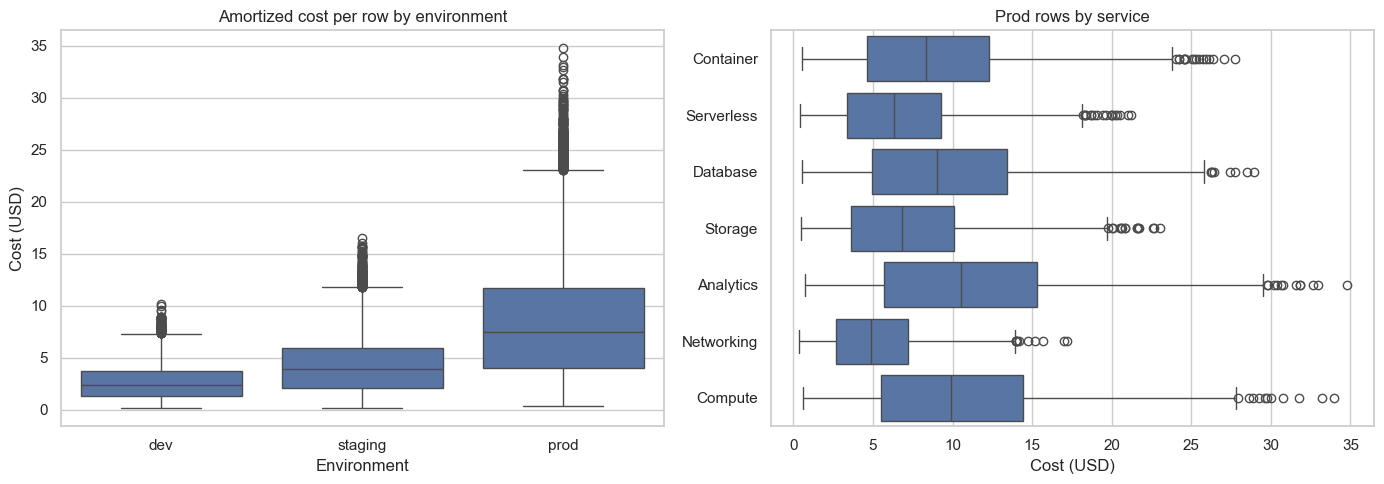

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='environment', y='amortized_cost', order=['dev', 'staging', 'prod'], ax=axes[0])
axes[0].set_title('Amortized cost per row by environment')
axes[0].set_xlabel('Environment')
axes[0].set_ylabel('Cost (USD)')

sns.boxplot(data=df[df['environment'] == 'prod'], x='amortized_cost', y='service', ax=axes[1])
axes[1].set_title('Prod rows by service')
axes[1].set_xlabel('Cost (USD)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

All the outlier rows are from prod, mostly Analytics, Compute and Database. These look like real expensive workloads and not bad data, so I'm keeping them. Dropping them would make the forecast too low.

### Daily level

The model will use the total cost per day, so I also check the daily totals.

In [10]:
daily_cost = df.groupby('date')['amortized_cost'].sum()

q1 = daily_cost.quantile(0.25)
q3 = daily_cost.quantile(0.75)
high_days = daily_cost[daily_cost > q3 + 1.5 * (q3 - q1)]
print('high days:', len(high_days))
print(high_days.round(0))

high days: 7
date
2023-11-08    1357.0
2023-11-15    1356.0
2023-11-24    1350.0
2023-11-29    1343.0
2023-12-01    1343.0
2023-12-04    1387.0
2023-12-25    1436.0
Name: amortized_cost, dtype: float64


Only 7 high days, and all of them are in November and December. Spend goes up overall in those months (see the trend chart below), so these are not one-off spikes. I'm keeping them.

I also noticed that `forecast_monthly_cost` and the budget columns don't line up with the actual costs. The forecast column keeps growing toward the end of each month, and budget utilization never goes above about 4%. So I'm not using the budget columns. I'll compare my forecast to actual spend instead.

## 4. Feature engineering

In [11]:
df['is_weekend'] = df['day_of_week'] >= 5
df['savings_rate'] = (df['list_cost'] - df['amortized_cost']) / df['list_cost']

df[['savings_rate']].describe()

,savings_rate
count,54750.000000
mean,0.319524
std,0.105198
min,0.056615
25%,0.239472
50%,0.323818
75%,0.400776
max,0.642018


- `is_weekend`: to see if weekends cost less.
- `savings_rate`: how much of the list price is saved through discounts and commitments.

Now I build the daily table that the forecast uses, plus a few columns for EDA.

In [12]:
daily = daily_cost.to_frame('cost')
daily['day_of_week'] = daily.index.dayofweek
daily['is_weekend'] = daily['day_of_week'] >= 5
daily['month'] = daily.index.month
daily['lag_7'] = daily['cost'].shift(7)          # same day last week
daily['rolling_7'] = daily['cost'].rolling(7).mean()

daily.dropna().head()

,cost,day_of_week,is_weekend,month,lag_7,rolling_7
date,,,,,,
2023-01-08,711.5791,6,True,1,674.3746,849.631771
2023-01-09,829.1512,0,False,1,979.4942,828.154200
2023-01-10,962.8798,1,False,1,887.0242,838.990714
2023-01-11,942.6253,2,False,1,902.8588,844.671643
2023-01-12,947.7564,3,False,1,856.3705,857.726771


## 5. EDA

### Spend by category

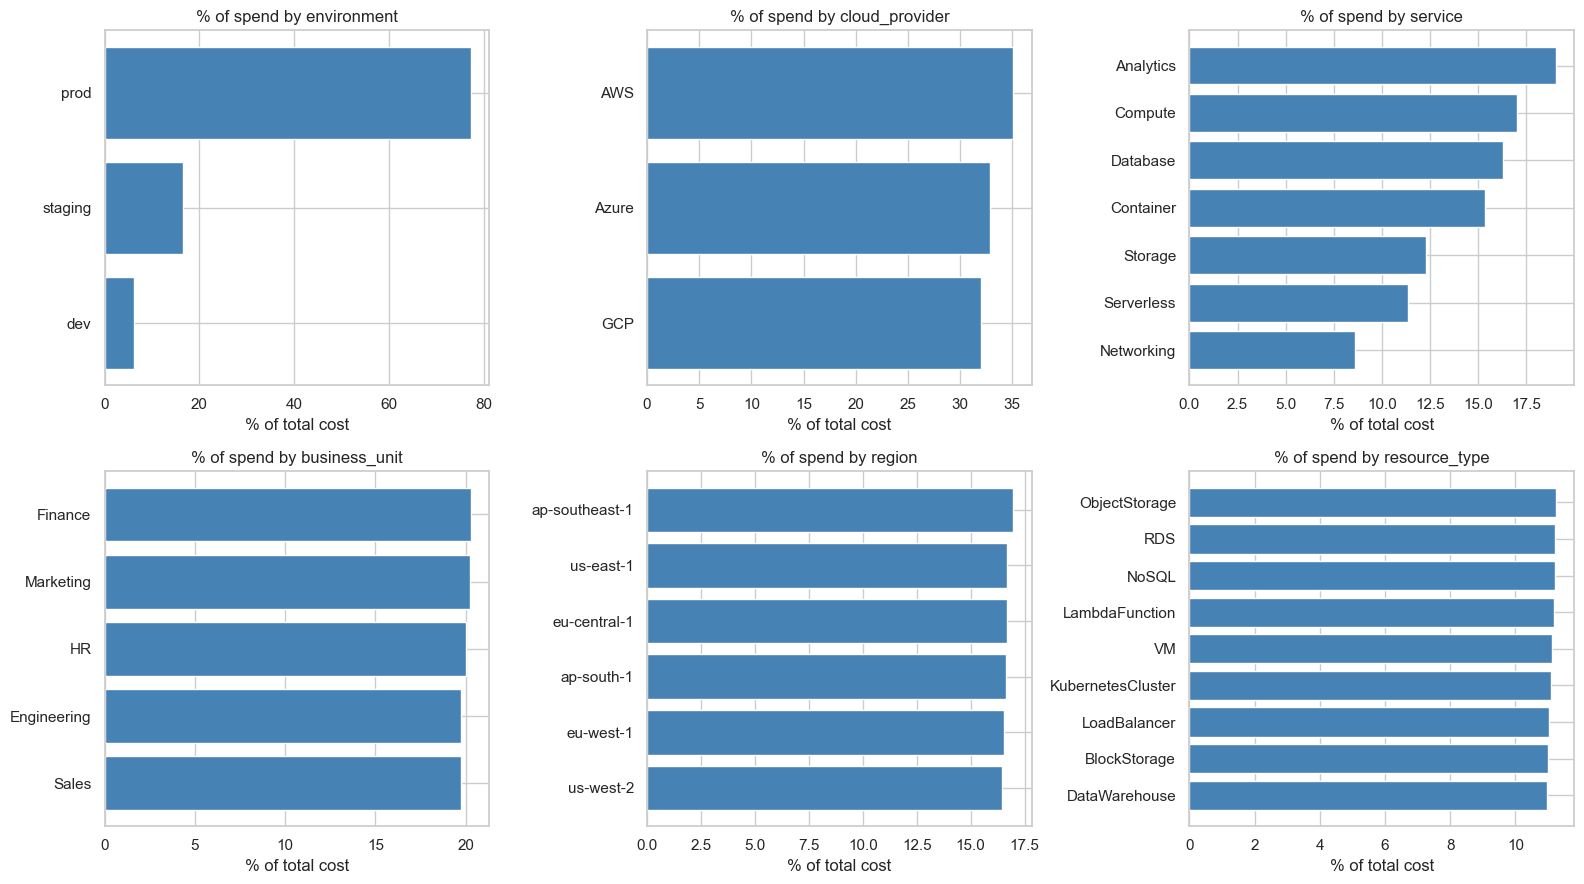

In [13]:
cat_cols = ['environment', 'cloud_provider', 'service', 'business_unit', 'region', 'resource_type']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    share = df.groupby(col)['amortized_cost'].sum() / df['amortized_cost'].sum() * 100
    share = share.sort_values()
    ax.barh(share.index, share.values, color='steelblue')
    ax.set_title(f'% of spend by {col}')
    ax.set_xlabel('% of total cost')

plt.tight_layout()
plt.savefig('images/spend_by_category.png', dpi=100)
plt.show()

Prod is about 77% of the total spend, staging 17% and dev 6%. Analytics and Compute are the biggest services. Providers, business units and regions are split almost evenly, so they probably won't explain much.

### Continuous columns

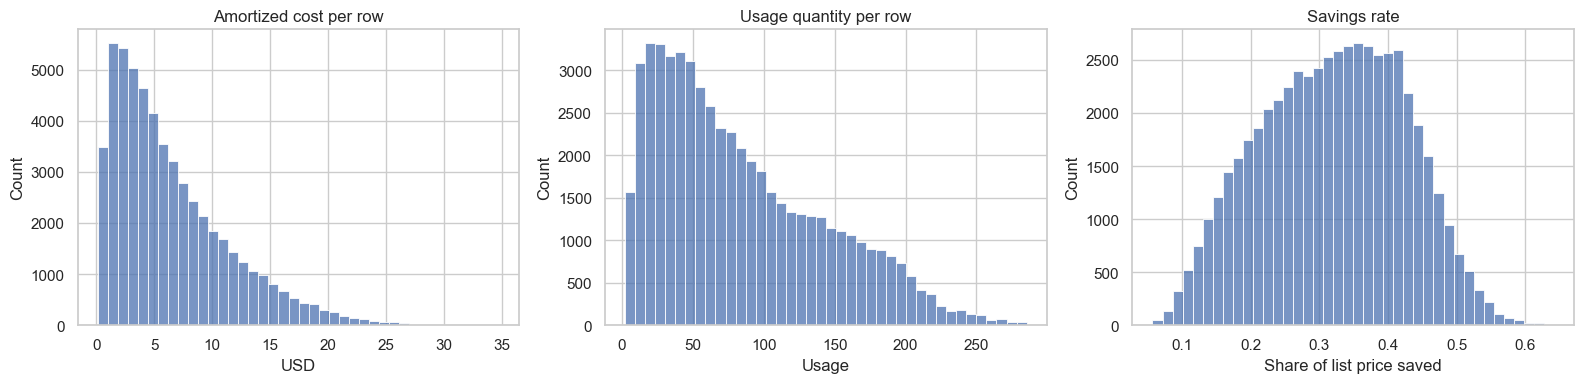

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['amortized_cost'], bins=40, ax=axes[0])
axes[0].set_title('Amortized cost per row')
axes[0].set_xlabel('USD')

sns.histplot(df['usage_quantity'], bins=40, ax=axes[1])
axes[1].set_title('Usage quantity per row')
axes[1].set_xlabel('Usage')

sns.histplot(df['savings_rate'], bins=40, ax=axes[2])
axes[2].set_title('Savings rate')
axes[2].set_xlabel('Share of list price saved')

plt.tight_layout()
plt.show()

Cost and usage are right skewed. Most rows are small, and a smaller number of prod rows make up a big part of the total. On average about a third of the list price gets saved.

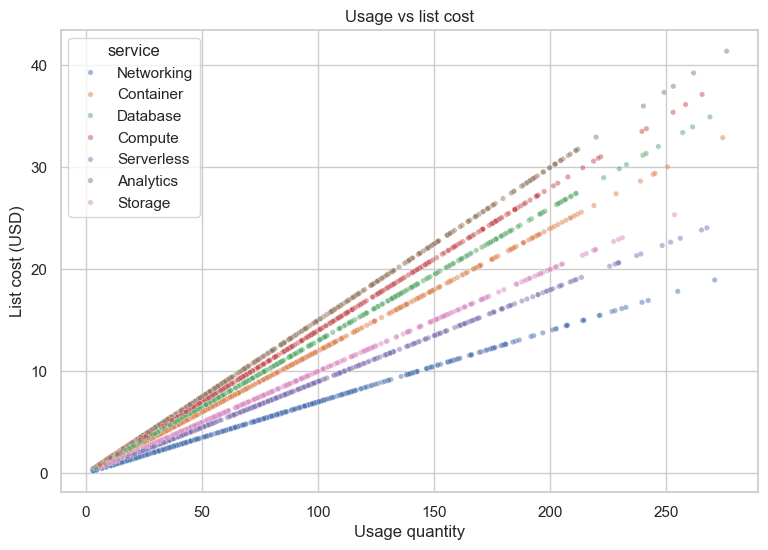

correlation: 0.93


In [15]:
sample = df.sample(3000, random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x='usage_quantity', y='list_cost', hue='service', alpha=0.5, s=15)
plt.title('Usage vs list cost')
plt.xlabel('Usage quantity')
plt.ylabel('List cost (USD)')
plt.show()

print('correlation:', round(df['usage_quantity'].corr(df['list_cost']), 2))

Usage and cost are strongly related (0.93), and each service has its own price per unit, which is why there are separate lines. My proposal said I'd use CPU/RAM/storage utilization as predictors, but the dataset doesn't have those. `usage_quantity` is the only usage metric.

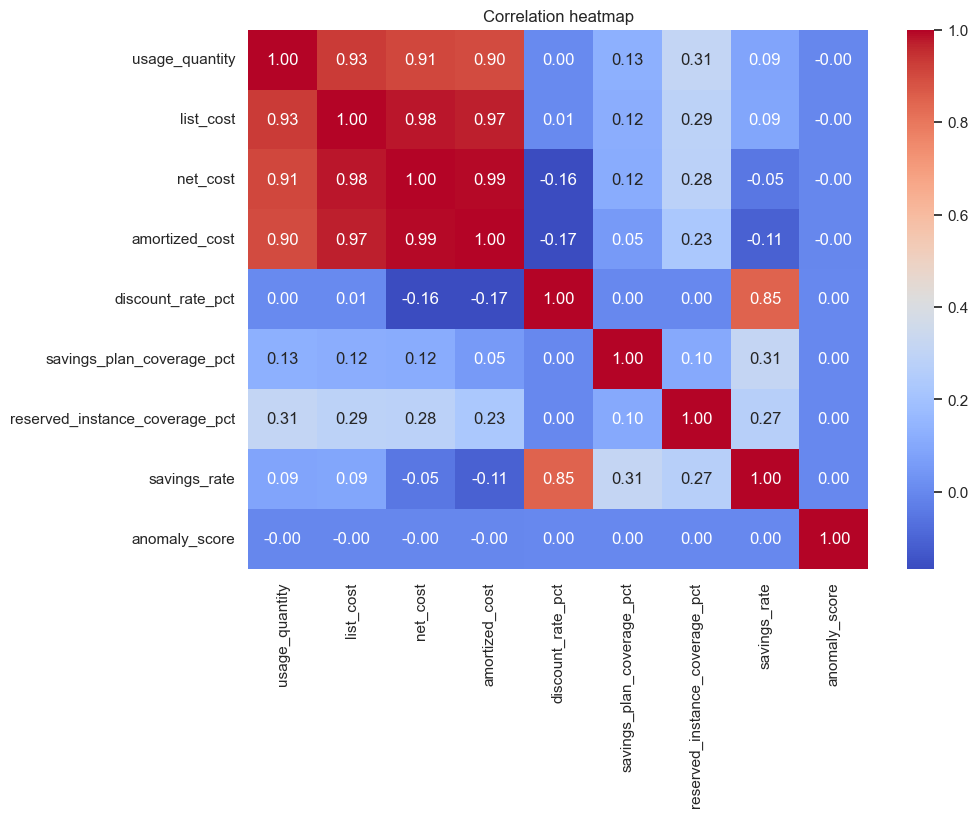

In [16]:
num_cols = ['usage_quantity', 'list_cost', 'net_cost', 'amortized_cost', 'discount_rate_pct',
            'savings_plan_coverage_pct', 'reserved_instance_coverage_pct', 'savings_rate', 'anomaly_score']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

The cost columns are almost perfectly correlated with each other, since they're all versions of the same number. Coverage, discount and anomaly score barely relate to cost.

### Cost over time

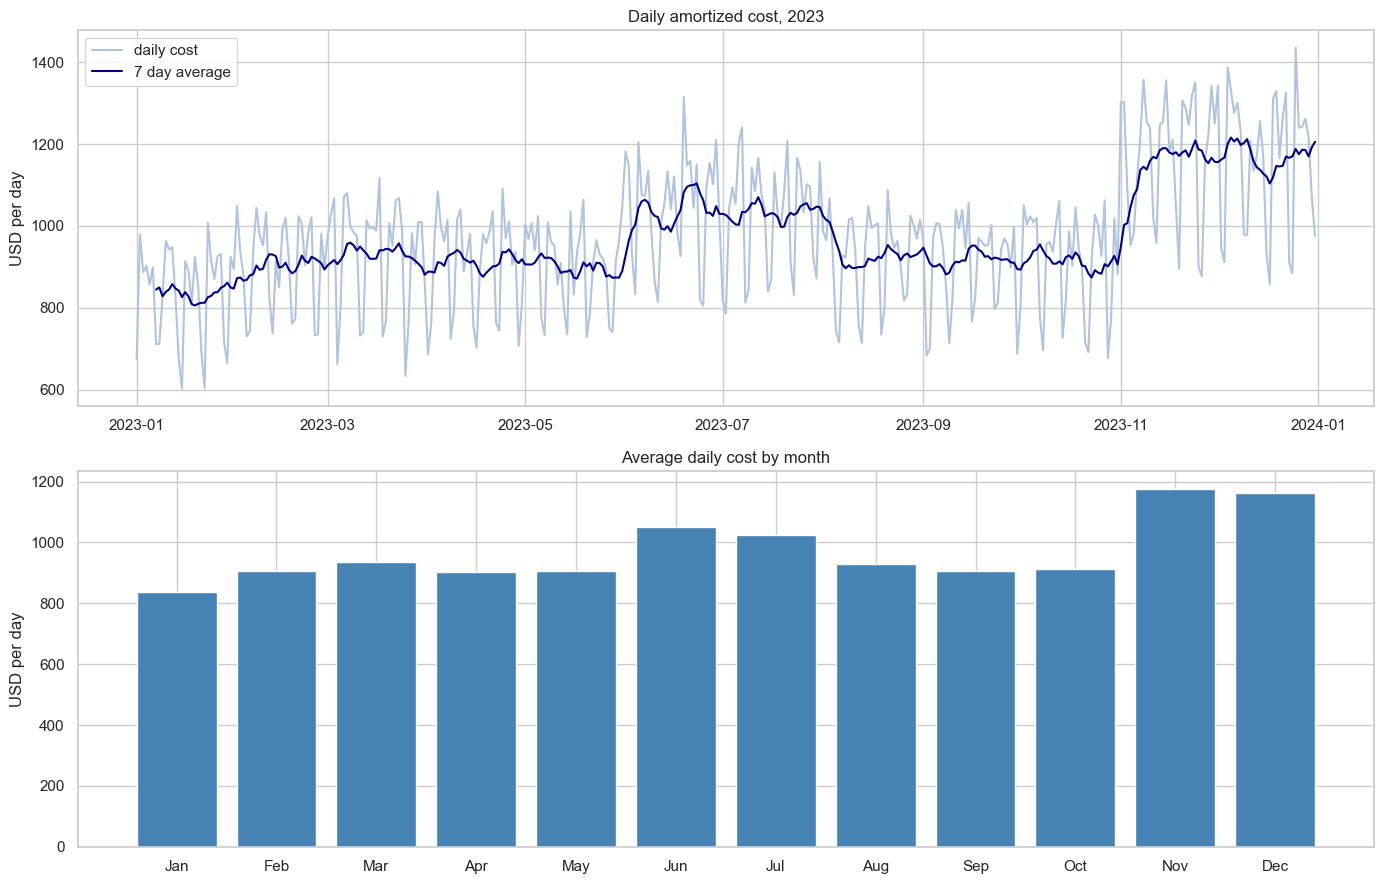

date
2023-01-01     837.0
2023-02-01     906.0
2023-03-01     935.0
2023-04-01     903.0
2023-05-01     906.0
2023-06-01    1051.0
2023-07-01    1025.0
2023-08-01     928.0
2023-09-01     908.0
2023-10-01     914.0
2023-11-01    1175.0
2023-12-01    1163.0
Freq: MS, Name: cost, dtype: float64


In [17]:
monthly_avg = daily['cost'].resample('MS').mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(daily.index, daily['cost'], color='lightsteelblue', label='daily cost')
axes[0].plot(daily.index, daily['rolling_7'], color='navy', label='7 day average')
axes[0].set_title('Daily amortized cost, 2023')
axes[0].set_ylabel('USD per day')
axes[0].legend()

axes[1].bar(monthly_avg.index.strftime('%b'), monthly_avg.values, color='steelblue')
axes[1].set_title('Average daily cost by month')
axes[1].set_ylabel('USD per day')

plt.tight_layout()
plt.savefig('images/daily_cost_trend.png', dpi=100)
plt.show()

print(monthly_avg.round(0))

Cost goes up slowly in the first half of the year, has a bump in June/July, then jumps in November (about 29% higher than October) and stays high in December. These jumps will be the hardest part to forecast.

### Weekly pattern

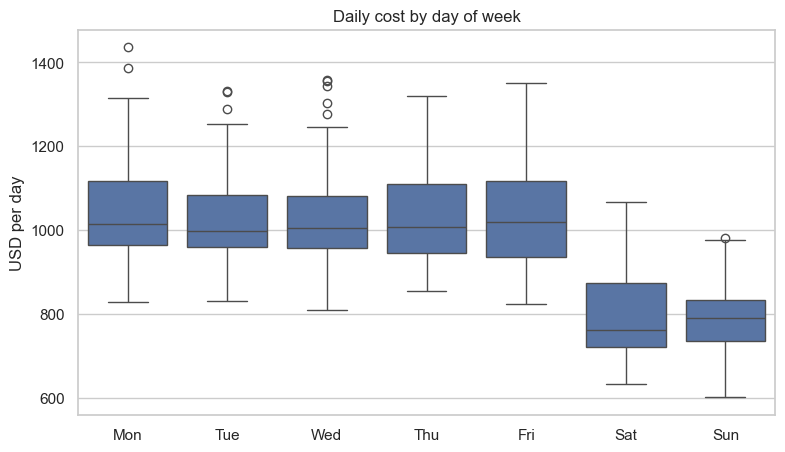

is_weekend
False    1042.0
True      796.0
Name: cost, dtype: float64


In [18]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=daily, x='day_of_week', y='cost')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.title('Daily cost by day of week')
plt.xlabel('')
plt.ylabel('USD per day')
plt.savefig('images/weekly_pattern.png', dpi=100)
plt.show()

print(daily.groupby('is_weekend')['cost'].mean().round(0))

In [19]:
# weekend vs weekday by environment
env_daily = df.groupby(['date', 'environment', 'is_weekend'])['amortized_cost'].sum().reset_index()
env_daily.groupby(['environment', 'is_weekend'])['amortized_cost'].mean().unstack().round(0)

is_weekend,False,True
environment,,
dev,63.0,51.0
prod,805.0,615.0
staging,173.0,130.0


Weekends are about 24% cheaper than weekdays ($796 vs $1,042 per day) and this happens in every environment. So there is a clear 7 day pattern, and the SARIMA model should use a weekly season (s = 7).

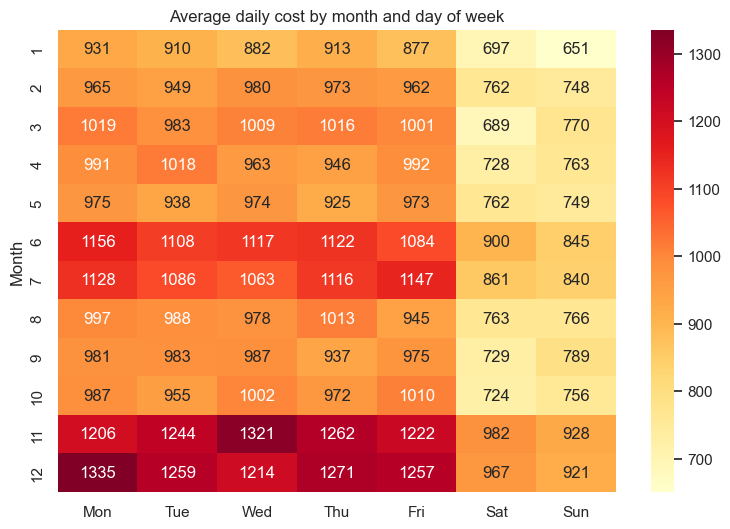

In [20]:
pivot = daily.pivot_table(index='month', columns='day_of_week', values='cost')
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Average daily cost by month and day of week')
plt.ylabel('Month')
plt.show()

The heatmap shows both things together: weekends are lighter in every month, and Nov/Dec are darker across the whole week.

## 6. Time series checks

### Decomposition

My proposal planned a multi-seasonal decomposition. The data is daily so there's no within-day cycle. I'm using MSTL with a weekly (7) and a monthly (30) season to see which ones are actually there.

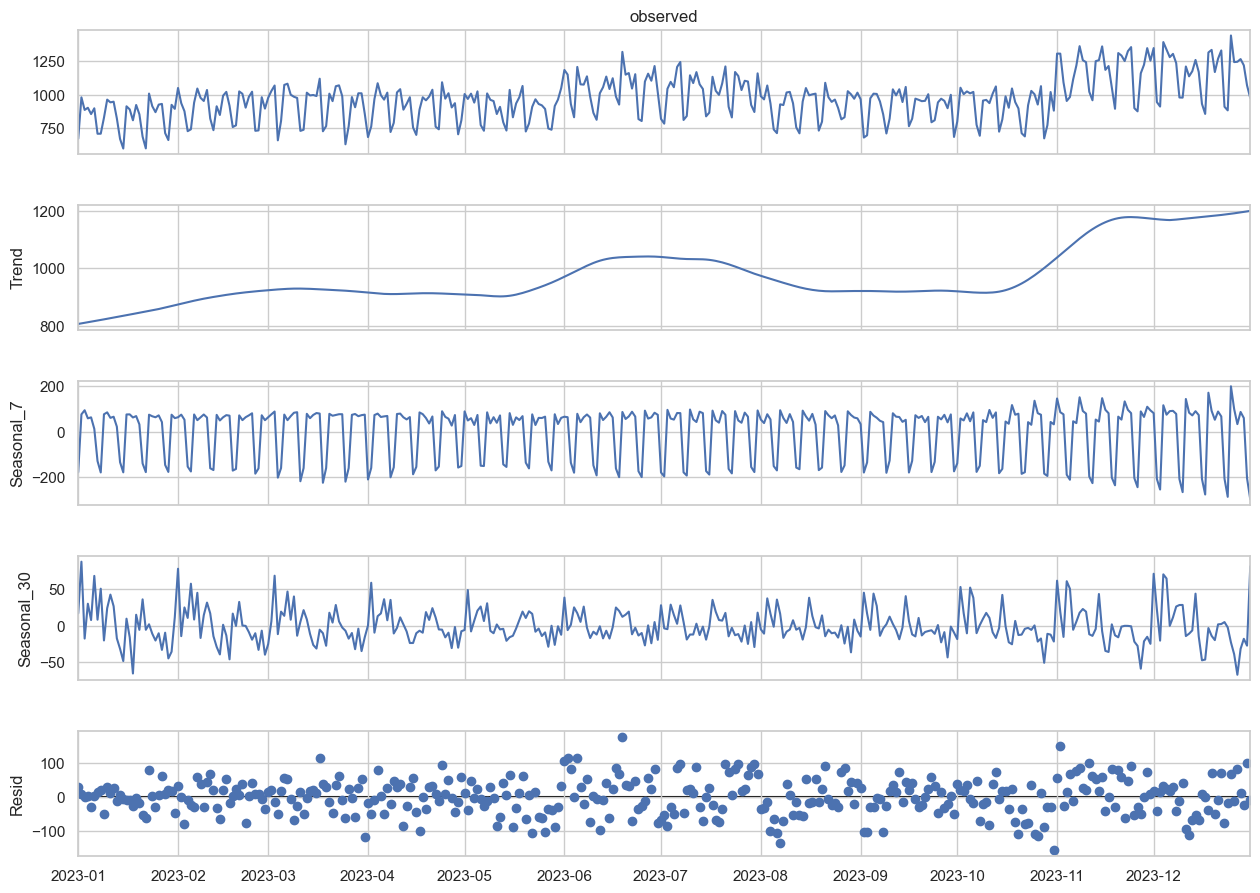

In [21]:
decomp = MSTL(daily['cost'], periods=(7, 30)).fit()
decomp.plot()
plt.gcf().set_size_inches(14, 10)
plt.show()

The weekly season is strong. The monthly season is very small compared to it, so I'm only modeling the weekly one. The trend shows the same jumps as before.

### Stationarity (ADF test)

In [22]:
def adf_test(series, name):
    p_value = adfuller(series.dropna())[1]
    print(f'{name}: p-value = {p_value:.4f}')

adf_test(daily['cost'], 'original')
adf_test(daily['cost'].diff(7), 'weekly difference')
adf_test(daily['cost'].diff(7).diff(), 'weekly + first difference')

original: p-value = 0.7395
weekly difference: p-value = 0.0032
weekly + first difference: p-value = 0.0000


The original series isn't stationary (p = 0.74). After a weekly difference it is (p < 0.05). So I'll use D = 1 with s = 7, and also try d = 1 because of the jumps in the trend.

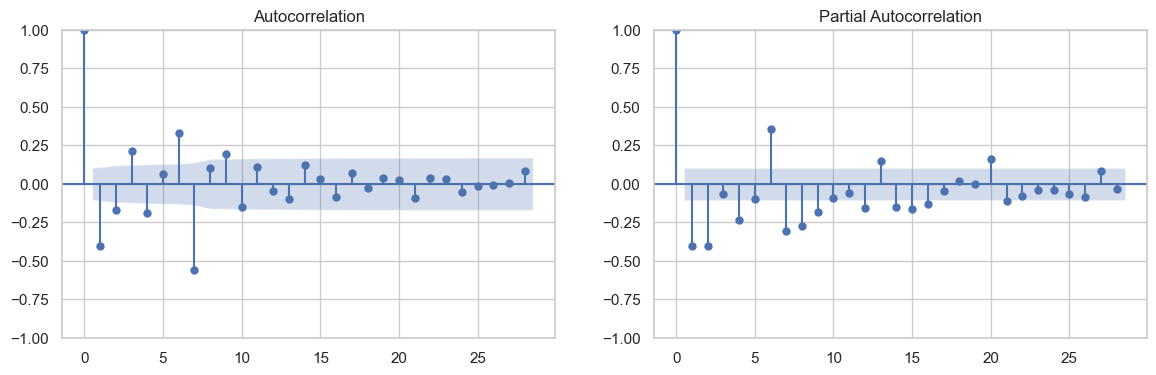

In [23]:
diffed = daily['cost'].diff(7).diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diffed, lags=28, ax=axes[0])
plot_pacf(diffed, lags=28, ax=axes[1])
plt.show()

The biggest spikes are at lag 1 and lag 7, so small MA terms and a seasonal MA term should be enough. I'll try a few options and pick the one with the lowest AIC.

## 7. Baseline model

### Train / test split

This is time series data, so I can't split randomly. I train on January to November and test on December.

In [24]:
train = daily['cost'][:'2023-11-30']
test = daily['cost']['2023-12-01':]
print('train:', len(train), 'days')
print('test:', len(test), 'days')

train: 334 days
test: 31 days


### Metric

I'm using MAPE (mean absolute percentage error) as the main metric, same as in my proposal. It's easy to explain ("the forecast is off by about 6% per day") and doesn't depend on how big the budget is. MAPE can break when actual values are close to 0, but daily cost here is never below about $600, so that's fine. I'm also showing MAE and RMSE in dollars.

### Simple baselines

To know if SARIMA is any good, I compare it with two simple forecasts:
- Naive: every day in December = the last day of November.
- Seasonal naive: repeat the last week of November.

In [25]:
def get_scores(actual, pred):
    return {
        'MAPE %': round(mean_absolute_percentage_error(actual, pred) * 100, 2),
        'MAE': round(mean_absolute_error(actual, pred), 2),
        'RMSE': round(root_mean_squared_error(actual, pred), 2)
    }

naive_pred = pd.Series(train.iloc[-1], index=test.index)

last_week = train.iloc[-7:].values
seasonal_naive_pred = pd.Series(np.tile(last_week, 5)[:len(test)], index=test.index)

results = pd.DataFrame({
    'naive': get_scores(test, naive_pred),
    'seasonal naive': get_scores(test, seasonal_naive_pred)
}).T
results

,MAPE %,MAE,RMSE
naive,13.88,140.64,188.04
seasonal naive,7.29,86.97,112.44


### SARIMA

I'm trying a few SARIMA orders based on the ACF/PACF plots and picking the one with the lowest AIC on the training data.

In [26]:
options = [
    ((1, 1, 1), (1, 1, 1, 7)),
    ((0, 1, 1), (0, 1, 1, 7)),
    ((0, 1, 2), (0, 1, 1, 7)),
    ((1, 1, 0), (1, 1, 0, 7)),
    ((1, 0, 1), (0, 1, 1, 7))
]

for order, seasonal in options:
    model = SARIMAX(train, order=order, seasonal_order=seasonal,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    print(order, seasonal, 'AIC:', round(model.aic, 1))

(1, 1, 1) (1, 1, 1, 7) AIC: 3607.7
(0, 1, 1) (0, 1, 1, 7) AIC: 3606.8


(0, 1, 2) (0, 1, 1, 7) AIC: 3594.7
(1, 1, 0) (1, 1, 0, 7) AIC: 3762.0
(1, 0, 1) (0, 1, 1, 7) AIC: 3617.5


SARIMA(0,1,2)(0,1,1,7) has the lowest AIC, so I'm using that one.

In [27]:
sarima = SARIMAX(train, order=(0, 1, 2), seasonal_order=(0, 1, 1, 7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

forecast = sarima.get_forecast(steps=len(test))
sarima_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

results.loc['SARIMA'] = get_scores(test, sarima_pred)
results

,MAPE %,MAE,RMSE
naive,13.88,140.64,188.04
seasonal naive,7.29,86.97,112.44
SARIMA,6.40,70.69,83.60


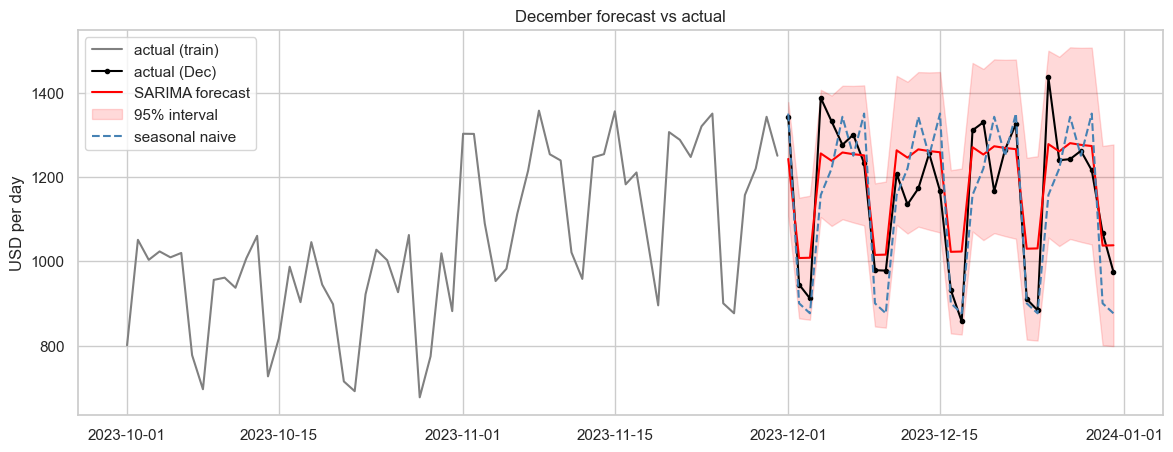

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(train['2023-10-01':], color='gray', label='actual (train)')
plt.plot(test, color='black', marker='o', markersize=3, label='actual (Dec)')
plt.plot(sarima_pred, color='red', label='SARIMA forecast')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.15, label='95% interval')
plt.plot(seasonal_naive_pred, color='steelblue', linestyle='--', label='seasonal naive')
plt.title('December forecast vs actual')
plt.ylabel('USD per day')
plt.legend()
plt.savefig('images/december_forecast.png', dpi=100)
plt.show()

In [29]:
print('December actual total:   ', round(test.sum()))
print('December SARIMA forecast:', round(sarima_pred.sum()))
print('difference %:', round((sarima_pred.sum() / test.sum() - 1) * 100, 1))

December actual total:    36038
December SARIMA forecast: 36721
difference %: 1.9


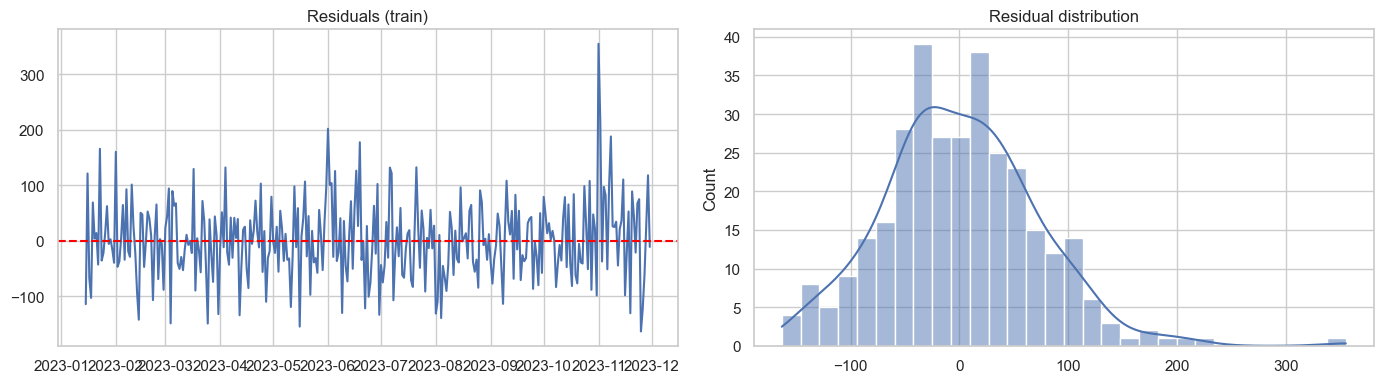

In [30]:
# residuals should look like random noise around 0
residuals = sarima.resid[14:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(residuals)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals (train)')
sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Residual distribution')
plt.tight_layout()
plt.show()

The residuals are centered around 0 and don't show a clear pattern, so the model is picking up the weekly cycle and trend fine.

## 8. Findings and next steps

Findings:
- The data was already clean (no missing values, no duplicates, no missing days). I only dropped 5 columns that had one value or repeated other columns.
- Prod is about 77% of the spend. Provider, region and business unit are split almost evenly.
- The outliers are real prod costs, so I kept them.
- Weekends are about 24% cheaper than weekdays, so there's a strong weekly pattern.
- Cost jumps in June/July and again in November (about 29% higher than October).
- SARIMA(0,1,2)(0,1,1,7) got a MAPE of 6.4% on December, compared with 13.9% for the naive forecast and 7.3% for the seasonal naive. The December total was off by only 1.9%.

Next steps:
- Look into the jumps in the trend. A model trained only up to October would not see the November jump coming.
- Try other models using the lag and weekend features.
- Test on more than one month to make sure the results hold up.
- Try forecasting prod, staging and dev separately and adding them up.